# HDT 3: Inferencia, Naive Bayes y Regresión

**Ciencia de Datos, Sección A** · Asignada: jueves 20 de agosto · **Entrega: jueves 27 de agosto, 23:59**

**Nombre:** _(escribir aquí)_

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la mini-bitácora del final.

## Setup

Dependencias: `pip install numpy pandas matplotlib seaborn scikit-learn`. Todo es determinista (semillas fijas y datasets estáticos): las verificaciones son exactas.

In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Parte A · Inferencia y A/B testing (0.5 pt)

El experimento del botón, en grande: 50,000 visitantes por grupo. La tasa real del control es 10.0% y la de la variante 10.5%: un efecto **pequeño** con una muestra **enorme**. Ese contraste es el tema de la parte D.

### Ejercicio 1 (0.15): la diferencia y su intervalo

(a) La diferencia observada `obs` entre variante y control. (b) El error estándar de la diferencia: $\sqrt{s_a^2/n + s_b^2/n}$ con `var(ddof=1)`. (c) El intervalo del 95%: `obs` ± 1.96 × SE. ¿El intervalo incluye el cero?

In [57]:
rng = np.random.default_rng(9)
n_ab = 50_000
control = rng.binomial(1, 0.100, n_ab)
variante = rng.binomial(1, 0.105, n_ab)

obs = variante.mean() - control.mean()   # ¿Qué va aquí?
se = np.sqrt(variante.var(ddof=1)/n_ab + control.var(ddof=1)/n_ab)   # ¿Qué va aquí?
# imprimir el intervalo
print(f"Intervalo de confianza: [{obs - 1.96 * se:.5f}, {obs + 1.96 * se:.5f}]")
print("¿Incluye el cero?", (obs - 1.96 * se) <= 0 <= (obs + 1.96 * se))
# Verificación (descomentar):
assert round(obs, 5) == 0.00506
assert round(obs - 1.96 * se, 5) == 0.00132

Intervalo de confianza: [0.00132, 0.00880]
¿Incluye el cero? False


### Ejercicio 2 (0.20): test de permutación desde cero

Si el botón no importara, las etiquetas serían intercambiables. Completar la función: concatenar, revolver `reps` veces, partir en dos grupos del tamaño original, guardar la diferencia, y devolver la fracción de diferencias tan extremas como la observada.

In [58]:
def test_permutacion(a, b, reps=3000, seed=1):
    rng_p = np.random.default_rng(seed)
    obs_ = b.mean() - a.mean()
    # ¿Qué va aquí?
    # 1) todos = concatenar a y b
    todos = np.concatenate([a, b])
    # 2) reps veces: rng_p.shuffle(todos) y partir en dos
    dif = []
    for _ in range(reps):
        rng_p.shuffle(todos)
        half = len(todos) // 2
        a_shuffled = todos[:half]
        b_shuffled = todos[half:]
        # 3) guardar la diferencia de medias de cada partición
        dif.append(b_shuffled.mean() - a_shuffled.mean())
    # 4) devolver la fracción con |dif| >= |obs_|
    return np.mean(np.abs(dif) >= np.abs(obs_))

p_val = test_permutacion(control, variante)   # aplicarla a control y variante

# Verificación (descomentar):
assert round(p_val, 3) == 0.008

### Ejercicio 3 (0.15): 100 tests bajo $H_0$

Ningún efecto existe: los dos grupos vienen de la misma Normal. Contar cuántos "descubrimientos" aparecen con $\alpha = 0.05$ (umbral 1.96) y cuántos sobreviven Bonferroni ($\alpha/100$, umbral 3.48).

In [59]:
def z(a_, b_):
    s = np.sqrt(a_.var()/len(a_) + b_.var()/len(b_))
    return (b_.mean() - a_.mean()) / s

rng3 = np.random.default_rng(2)
significativos = 0
significativos_bonf = 0

for i in range(100):
    g1 = rng3.normal(0, 1, 500)
    g2 = rng3.normal(0, 1, 500)   # exactamente la misma distribución
    # ¿Qué va aquí? contar |z| > 1.96 y |z| > 3.48
    zi = z(g1, g2)
    if abs(zi) > 1.96:
        significativos += 1
    if abs(zi) > 3.48:
        significativos_bonf += 1

print(f"Significativos: {significativos}, Significativos con Bonferroni: {significativos_bonf}")
# Verificación (descomentar):
assert significativos == 3 and significativos_bonf == 0

Significativos: 3, Significativos con Bonferroni: 0


## Parte B · Naive Bayes (0.5 pt)

Un filtro de spam para mensajes de texto, desde cero, como en la sesión 7. El corpus:

In [60]:
textos = [
    "gana un premio reclamalo hoy mismo",
    "oferta exclusiva solo por hoy haz clic",
    "felicidades fuiste seleccionado para un premio",
    "crédito preaprobado sin requisitos aplica ya",
    "última oportunidad descuento del 90 por ciento",
    "tu cuenta será suspendida verifica tus datos",
    "recarga doble gratis si respondes ya",
    "has ganado un viaje reclama tu premio aquí",
    "nos vemos a las 8 en la u",
    "ya voy en camino llego en 10",
    "mamá dice que compres tortillas",
    "el partido quedó 2 a 1 increíble",
    "te mando el resumen de la clase en la noche",
    "feliz cumple nos vemos el sábado",
    "se me olvidó la usb me la prestas",
    "la tarea es para el martes no para hoy",
]

etiquetas = ["spam"] * 8 + ["normal"] * 8

test_x = [
    "reclama tu premio gratis haz clic ya",
    "llego en 5 nos vemos en la entrada",
    "oferta solo hoy tu crédito ya está aprobado",
    "la clase se movió para el jueves",
]
test_y = ["spam", "normal", "spam", "normal"]

print(len(textos), len(etiquetas), len(test_x))

16 16 4


### Ejercicio 4 (0.15): bolsa de palabras

(a) `vocab`: la lista **ordenada** de palabras únicas del corpus de entrenamiento. (b) `idx`: diccionario palabra → posición. (c) `conteos` (matriz clases × |V|) y `priors`, contando sobre `textos`.

In [61]:
def tokenizar(texto):
    return texto.lower().split()

clases = sorted(set(etiquetas))   # ["normal", "spam"]

# ¿Qué va aquí?

# (a) vocabulario ordenado y sin repetidos
vocab = sorted({w for t in textos for w in tokenizar(t)})

# (b) traductor palabra -> columna
idx = {w: i for i, w in enumerate(vocab)}

# (c) entrenar es contar: un recorrido, dos acumuladores
conteos = np.zeros((len(clases), len(vocab)))
priors = np.zeros(len(clases))

for texto, y in zip(textos, etiquetas):
    c = clases.index(y)
    priors[c] += 1
    for w in tokenizar(texto):
        conteos[c, idx[w]] += 1

print("clases:", clases)
print("vocabulario:", len(vocab), "palabras")
print("conteos:", conteos.shape)
print("priors (crudos):", priors)

assert len(vocab) == 86
assert conteos.shape == (2, 86)
assert priors.tolist() == [8.0, 8.0]

clases: ['normal', 'spam']
vocabulario: 86 palabras
conteos: (2, 86)
priors (crudos): [8. 8.]


### Ejercicio 5 (0.20): entrenar con Laplace y clasificar

(a) Suavizar: `conteos + 1`. (b) `log_veros` (normalizar por fila y tomar log) y `log_prior`. (c) `puntajes(texto)` que suma log-prior más log-verosimilitud de cada palabra **conocida**, y `predecir(texto)` con el argmax. (d) Clasificar los 4 mensajes de prueba.

In [62]:
# ¿Qué va aquí?
suavizado = conteos + 1

log_priors = np.log(priors / priors.sum())
log_veros = np.log(suavizado / suavizado.sum(axis=1, keepdims=True))

def puntajes(texto):
    p = log_priors.copy()
    for w in tokenizar(texto):
        if w in idx:
            p += log_veros[:, idx[w]]
    return p

def predecir(texto):
    return clases[int(np.argmax(puntajes(texto)))]

for t, real in zip(test_x, test_y):
    print(f"{predecir(t):7} (real: {real:7}) <- {t}")

# Verificación (descomentar):
assert [predecir(t) for t in test_x] == test_y

spam    (real: spam   ) <- reclama tu premio gratis haz clic ya
normal  (real: normal ) <- llego en 5 nos vemos en la entrada
spam    (real: spam   ) <- oferta solo hoy tu crédito ya está aprobado
normal  (real: normal ) <- la clase se movió para el jueves


### Ejercicio 6 (0.15): las palabras que delatan al spam

`ratio` = log-verosimilitud de spam menos la de normal. Con `np.argsort`, extraer las 5 palabras más spam (`informativas_spam`) y las 5 más normales (`informativas_normal`).

In [63]:
# ¿Qué va aquí?
# Pista: inv = {i: w for w, i in idx.items()}
inv = {i: w for w, i in idx.items()}

ratio = log_veros[1] - log_veros[0]
orden = np.argsort(ratio)

informativas_spam = [inv[i] for i in orden[::-1][:5]]
informativas_normal = [inv[i] for i in orden[:5]]

print("Palabras más informativas para spam:", informativas_spam)
print("Palabras más informativas para normal:", informativas_normal)

# Verificación (descomentar):
assert informativas_spam[0] == "premio"

Palabras más informativas para spam: ['premio', 'un', 'por', 'tu', 'última']
Palabras más informativas para normal: ['la', 'en', 'el', 'me', 'vemos']


## Parte C · Regresión lineal (0.8 pt)

`diamonds`: 53,940 diamantes reales. La pregunta de negocio: ¿cuánto vale un quilate?

### Ejercicio 7 (0.20): EDA mínimo

(a) `shape` y `dtypes`. (b) Media y mediana de `price`: ¿cuál es mayor y qué dice eso de la cola? (c) El histograma de `price`.

(53940, 10)
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object
Media: 3932.8
Mediana: 2401.0


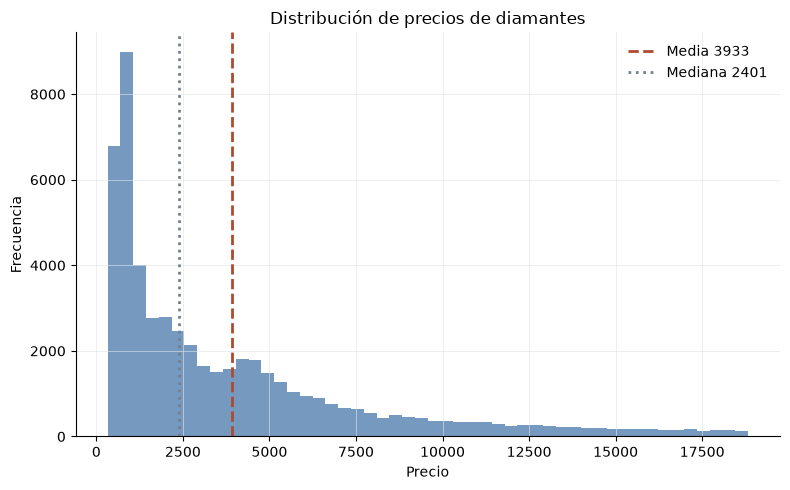

In [64]:
diamonds = sns.load_dataset("diamonds")

print(diamonds.shape)
print(diamonds.dtypes)

# ¿Qué va aquí?
media = diamonds["price"].mean()
mediana = diamonds["price"].median()

print("Media:", round(media, 2))
print("Mediana:", mediana)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(diamonds["price"], bins=50, color=AZUL, alpha=0.7)
ax.axvline(media, color=ROJO, lw=2, ls="--", label=f"Media {media:.0f}")
ax.axvline(mediana, color=GRIS, lw=2, ls=":", label=f"Mediana {mediana:.0f}")
ax.set_title("Distribución de precios de diamantes")
ax.set_xlabel("Precio")
ax.set_ylabel("Frecuencia")
ax.legend(frameon=False)
eje_limpio(ax)
plt.tight_layout()
plt.show()

# Verificación (descomentar):
assert diamonds.shape == (53940, 10)
assert diamonds["price"].median() == 2401.0

### Ejercicio 8 (0.20): OLS a mano

`price ~ carat` con las ecuaciones normales: (a) `Xb` con columna de unos y `np.linalg.solve`. (b) $R^2$ a mano (`r2_precio`). (c) Comparar contra `LinearRegression`.

In [65]:
from sklearn.linear_model import LinearRegression

x_c = diamonds["carat"].to_numpy(float)
y_p = diamonds["price"].to_numpy(float)

# ¿Qué va aquí?

def ols(x, y):
    beta = np.linalg.solve(x.T @ x, x.T @ y)
    pred = x @ beta
    r2 = 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return beta, pred, r2

Xb = np.column_stack([np.ones(len(x_c)), x_c])
beta_p, pred_p, r2_precio = ols(Xb, y_p)

lr = LinearRegression().fit(x_c.reshape(-1, 1), y_p)

print("Coeficientes:", f"{lr.coef_[0]:.2f}", f"{lr.intercept_:.2f}")
print("R^2:", f"{r2_precio:.3f}")
print("R^2 (sklearn):", f"{lr.score(x_c.reshape(-1, 1), y_p):.3f}")

# Verificación (descomentar):
assert round(r2_precio, 3) == 0.849

Coeficientes: 7756.43 -2256.36
R^2: 0.849
R^2 (sklearn): 0.849


### Ejercicio 9 (0.20): los residuos delatan, el log arregla

(a) Graficar residuos vs predicción del modelo del ejercicio 8. (b) Ajustar `log(price) ~ log(carat)` (`r2_log`) y graficar sus residuos. (c) Comparar los dos $R^2$ y las dos nubes.

log(precio) = 8.4487 + 1.6758 * log(quilates)
R2 nivel   = 0.8493
R2 log-log = 0.9330


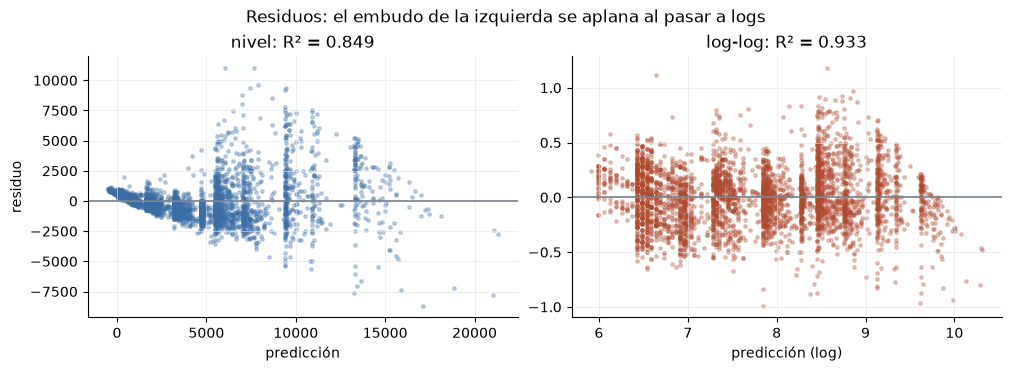

In [66]:
# ¿Qué va aquí?
# Pista: np.log para ambas variables; el patrón del gráfico
# de residuos está en el notebook de la sesión 8.5

# (a) residuos del modelo en nivel (el del ejercicio 8)
resid_p = y_p - pred_p

# (b) el mismo ajuste, pero en escala logarítmica
lx = np.log(x_c)
ly = np.log(y_p)
Xl = np.column_stack([np.ones(len(lx)), lx])
beta_l, pred_l, r2_log = ols(Xl, ly)
resid_l = ly - pred_l

print(f"log(precio) = {beta_l[0]:.4f} + {beta_l[1]:.4f} * log(quilates)")
print(f"R2 nivel   = {r2_precio:.4f}")
print(f"R2 log-log = {r2_log:.4f}")

# (c) las dos nubes de residuos, lado a lado
muestra = np.random.default_rng(0).choice(len(y_p), 4000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout="constrained")
axes[0].scatter(pred_p[muestra], resid_p[muestra], s=6, alpha=0.3, color=AZUL)
axes[0].set_title(f"nivel: R² = {r2_precio:.3f}")
axes[0].set_xlabel("predicción")
axes[0].set_ylabel("residuo")

axes[1].scatter(pred_l[muestra], resid_l[muestra], s=6, alpha=0.3, color=ROJO)
axes[1].set_title(f"log-log: R² = {r2_log:.3f}")
axes[1].set_xlabel("predicción (log)")

for ax in axes:
    ax.axhline(0, color=GRIS, lw=1.2)
    eje_limpio(ax)
fig.suptitle("Residuos: el embudo de la izquierda se aplana al pasar a logs")
plt.show()

# Verificación (descomentar):
assert round(r2_log, 3) == 0.933

### Ejercicio 10 (0.20): ¿y si agregamos más features?

Regresión múltiple en la escala log: `log(price) ~ log(carat) + depth + table`. Calcular `r2_multi` y responder en un comentario: ¿cuánto mejoró respecto al ejercicio 9?

In [67]:
# ¿Qué va aquí?
X3 = np.column_stack([
    np.ones(len(lx)),
    lx,
    diamonds["depth"].to_numpy(float),
    diamonds["table"].to_numpy(float),
])
beta_m, pred_m, r2_multi = ols(X3, ly)

print(f"R2 log-log simple  = {r2_log:.4f}")
print(f"R2 con depth+table = {r2_multi:.4f}")
print(f"mejora             = {r2_multi - r2_log:.4f}")

# Respuesta: mejoró apenas 0.0023 (0.933 -> 0.935). Dos variables más para explicar el precio 
# no es mucho, la variable carat es la que más explica el precio de un diamante.

# Verificación (descomentar):
assert round(r2_multi, 3) == 0.935

R2 log-log simple  = 0.9330
R2 con depth+table = 0.9353
mejora             = 0.0023


## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:

**(a)** El ejercicio 2 dio p = 0.008: el efecto del botón es estadísticamente real. El lift observado fue de medio punto porcentual (10.4% vs 9.9%). ¿Basta eso para lanzar el botón a producción? ¿Qué información falta para decidir?

**(b)** El modelo log-log del ejercicio 9 se ajustó con diamantes de hasta 5 quilates. ¿Por qué no es confiable usarlo para tasar un diamante de 8 quilates, aunque la fórmula produzca un número?

_(Responder editando esta celda)_

**Respuesta (a):** No basta ya que se debe tomar en cuenta que con pruebas peque;as como 50,000 muestras las diferencias más pequeñas se ven como muy significativas por lo que lo evidencia el mismo lift siendo así de bajo.

**Respuesta (b):** Porque con 8 quilates ya se está extrapolando el modelo y el mismo está ajustado para hasta 5 quilates por como la relación con nuestros log fueron estimados

## Mini-bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

**Mini-bitácora de AI (Claude):**

- Ejercicio 4: Se preguntó cómo se arma la bolsa de palabras a partir del corpus. Se entendió que `vocab` sale de un set comprehension con doble `for` sobre todos los textos (el set quita repetidos y `sorted` fija el orden), que `idx` es el traductor palabra → columna hecho con `enumerate`, y que "entrenar es contar": un solo recorrido con `zip(textos, etiquetas)` que suma 1 a `priors[c]` por documento y 1 a `conteos[c, idx[w]]` por palabra. También que `priors` guarda conteos crudos, sin normalizar.

- Ejercicio 5: Se preguntó por qué hay que suavizar y por qué se trabaja en logaritmos. Se entendió que `conteos + 1` (Laplace) evita que una palabra no vista en una clase tenga probabilidad cero y anule el producto entero, y que el log convierte productos en sumas para evitar el underflow. También dos detalles de implementación: `keepdims=True` al normalizar por fila, para que la suma de forma (2,1) se difunda sobre las 86 columnas; y `log_prior.copy()` dentro de `puntajes`, porque sin la copia cada `p +=` modificaría los log-priors originales y las predicciones siguientes saldrían mal.

- Ejercicio 7: Se preguntó por qué la gráfica mostraba una sola línea vertical en lugar de dos. Se entendió que `media` estaba calculada con `.median()` en vez de `.mean()`, así que ambas líneas caían en el mismo punto (2401). Con `.mean()` la media sale en 3932.80, a la derecha de la mediana, y esa brecha es justo la señal de la cola derecha que el ejercicio pide interpretar.

- Ejercicio 8: Se preguntó cómo resolver OLS con las ecuaciones normales. Se entendió que se arma `Xb` con `np.column_stack([np.ones(n), x])` — la columna de unos es la que produce el intercepto — y que `np.linalg.solve(X.T @ X, X.T @ y)` resuelve el sistema sin invertir la matriz. El R² se calcula a mano como `1 - SS_res/SS_tot`, y coincide con `LinearRegression` de sklearn hasta el último decimal (0.8493).

- Ejercicio 9: Se pidió ayuda para corregir la celda, que fallaba con `AttributeError: 'str' object has no attribute 'mean'`. Se entendió que la `y` que estaba usando era la variable sobrante del bucle del ejercicio 4 (valía "normal", un string), y que el ajuste log-log se hace aplicando `np.log` a ambas variables antes de repetir el mismo OLS. Lo importante no es que el R² suba de 0.849 a 0.933, sino que los residuos dejan de abrirse en embudo.